## Charmonia Suppression in pPb LHC Collision due to nPDF: Centrality Dependence

### Importing CNM

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ------------------------------------------------------------------
# Project paths (edit ONLY if your folder layout differs)
# ------------------------------------------------------------------
ROOT = Path.cwd()                  # where "npdf_code/" and "input/" live
NPDF_CODE_DIR = ROOT / "../npdf_code" # must contain: npdf_data.py, gluon_ratio.py, glauber.py, npdf_centrality.py

if str(NPDF_CODE_DIR) not in sys.path:
    sys.path.insert(0, str(NPDF_CODE_DIR))

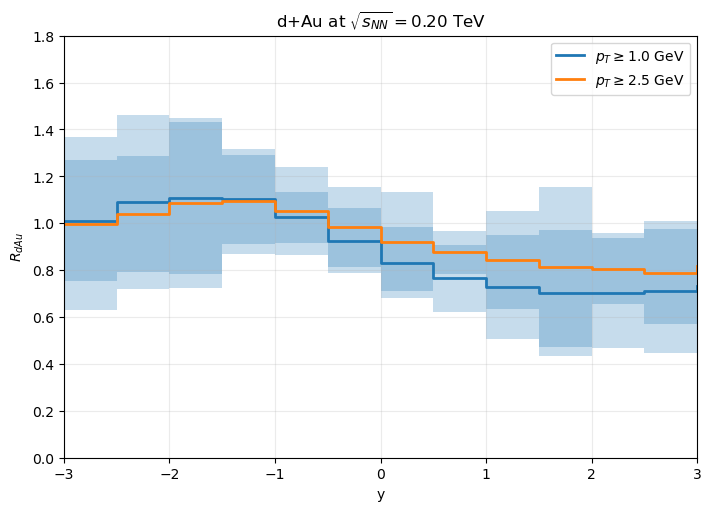

In [2]:
## Helpers
def centers_to_left_edges(centers: np.ndarray) -> np.ndarray:
    """
    Convert unevenly spaced centers -> left edges for step='post'.
    Length is the same as centers (last right-edge is implicit).
    """
    c = np.asarray(centers, float)
    c = np.unique(np.sort(c))
    if len(c) < 2:
        return c.copy()
    left = np.empty_like(c)
    left[0]  = c[0] - 0.5*(c[1] - c[0])
    left[1:] = 0.5*(c[:-1] + c[1:])
    return left

def step_band_xy(ax, x, y_c, y_lo, y_hi, label=None, color=None):
    """
    Draw a step band (like Mathematica ListStepPlot with filling).
    """
    ax.step(x, y_c, where="post", label=label, color=color, linewidth=2)
    ax.fill_between(x, y_lo, y_hi, step="post", alpha=0.25, color=color)

def style_axes(ax, xlab, ylab, grid=True, logx=False, logy=False, title=None):
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    if logx: ax.set_xscale("log")
    if logy: ax.set_yscale("log")
    if grid:
        ax.grid(True, which="both", alpha=0.25)
    if title:
        ax.set_title(title)



from npdf_data   import NPDFSystem, RpAAnalysis

dAu_dir  = "../input/npdf/dAu200GeV"
sys_dA = NPDFSystem.from_folder(dAu_dir,  kick="pp",  name="dAu 200 GeV")
ana = RpAAnalysis()

rgrid_dA = ana.compute_rpa_grid(sys_dA.df_pp, sys_dA.df_pa, sys_dA.df_errors, join="nearest")


### we can truncate from pT max
# 1. Setup a single figure
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

# 2. Assign and TRUNCATE the dAu data
sysX = sys_dA
# Filter rgrid to only include -3 <= y <= 3
rgrid = rgrid_dA[(rgrid_dA["y"] >= -3.0) & (rgrid_dA["y"] <= 3.5)].copy() ## or simply rgrid_dA

# 3. Compute data for both pt thresholds (now using the truncated grid)
vs_y_1   = ana.rpa_vs_y_pt_threshold(rgrid, sysX.df_pa, pt_min=1.0, pt_max=15.0)
vs_y_2p5 = ana.rpa_vs_y_pt_threshold(rgrid, sysX.df_pa, pt_min=2.5, pt_max=15.0)

# 4. Handle x-axis edges logic
# Note: Use the 'y' values from the computed dataframes to ensure edges match the truncation
x1 = centers_to_left_edges(vs_y_1["y"].values)
x2 = centers_to_left_edges(vs_y_2p5["y"].values)

# 5. Plot bands
step_band_xy(ax, x1, vs_y_1["r_central"], vs_y_1["r_lo"], vs_y_1["r_hi"],
             label=r"$p_T \geq 1.0$ GeV")
step_band_xy(ax, x2, vs_y_2p5["r_central"], vs_y_2p5["r_lo"], vs_y_2p5["r_hi"],
             label=r"$p_T \geq 2.5$ GeV")

# 6. Styling and Labels
style_axes(ax, "y", r"$R_{dAu}$") 
ax.set_ylim(0.0, 1.8)
ax.set_xlim(-3.0, 3.0) 
ax.set_title(r"d+Au at $\sqrt{s_{NN}} = 0.20$ TeV")
ax.legend()

plt.show()

In [3]:
# ------------------------------------------------------------------
# npdf_code imports
# ------------------------------------------------------------------
from npdf_data import NPDFSystem, RpAAnalysis
from gluon_ratio import EPPS21Ratio, GluonEPPSProvider
from glauber import OpticalGlauber, SystemSpec
from npdf_centrality_dAu import (
    compute_df49_by_centrality,
    make_centrality_weight_dict,
    bin_rpa_vs_y,
    bin_rpa_vs_pT,
    bin_rpa_vs_centrality,
)

print("[OK] Imported npdf_code modules.")

[OK] Imported npdf_code modules.


In [4]:
# ------------------------------------------------------------------
# Output toggles
# ------------------------------------------------------------------
SAVE_PDF   = True
SAVE_CSV   = True
DPI        = 150
ALPHA_BAND = 0.22

# ------------------------------------------------------------------
# Energy choice
# ------------------------------------------------------------------
ENERGY = "200" ## 200 GeV d+Au

# ------------------------------------------------------------------
# Centrality bins (edit freely)
# ------------------------------------------------------------------
CENT_BINS = [(0,20),(20,40),(40,60),(60,100)]

# ------------------------------------------------------------------
# Binning (edit freely)
# ------------------------------------------------------------------
Y_EDGES = np.arange(-3.0, 3.0 + 0.5, 0.5)
P_EDGES = np.arange(0.0, 12.0 + 2.5, 2.5)

Y_WINDOWS = [
    (-2.2, -1.2, "-2.2<y<-1.2"),
    (-0.35,  0.35, "-0.35 < y < 0.35"),
    (1.2,  2.2, "1.2 < y < 2.2"),
]

PT_RANGE_AVG = (0.0, 15.0)  # used for RpA(y) and RpA(cent)
PT_FLOOR_W   = 1.0          # low-pT weight floor (same idea as your CNM notebook)

# ------------------------------------------------------------------
# nPDF weighting knobs (KEEP FLEXIBLE)
# ------------------------------------------------------------------
WEIGHT_MODE      = "pp@local"
Y_REF            = 0.0
NB_BSAMPLES      = 5
Y_SHIFT_FRACTION = 1.0       # IMPORTANT knob you requested
MB_C0            = 0.25      # exp-weight parameter used for MB (same style as CNM notebook)

# ------------------------------------------------------------------
# Input locations (match your cnm_combine defaults)
# ------------------------------------------------------------------
NPDF_INPUT_DIR = ROOT / ".."/ "input" / "npdf"
dAu_dir = NPDF_INPUT_DIR / "dAu200GeV"
EPPS_DIR = NPDF_INPUT_DIR / "nPDFs"

SQRTS_GEV = {"200": 200.0}
SIG_NN_MB = {"200": 44.2} # mb cross-section (mb)

OUTDIR = ROOT / f"output-npdf-only-dAu-{ENERGY.replace('.','p')}"
OUTDIR.mkdir(exist_ok=True, parents=True)

print(f"[CFG] ENERGY={ENERGY} GeV, OUTDIR={OUTDIR}")

[CFG] ENERGY=200 GeV, OUTDIR=/home/sawin/Desktop/Charmonia/charmonia_combined_analysis/npdf_notebooks/output-npdf-only-dAu-200


In [5]:
## Loaders and builders
def build_npdf_context(
    energy: str,
    cent_bins,
    nb_bsamples: int = NB_BSAMPLES,
    y_shift_fraction: float = Y_SHIFT_FRACTION,
    pt_floor_w: float = PT_FLOOR_W,
    m_state_for_np="charmonium",   # <-- charmonia notebook; set to 3.0969 if you want J/psi mass explicitly
):
    if energy not in SQRTS_GEV:
        raise ValueError("energy must be '200'")

    sqrt_sNN = SQRTS_GEV[energy]
    sigma_nn_mb = SIG_NN_MB[energy]
    input_dir = dAu_dir

    # EPPS21 ratio + gluon provider
    epps_ratio = EPPS21Ratio(A=197, path=str(EPPS_DIR))
    gluon = GluonEPPSProvider(
        epps_ratio,
        sqrt_sNN_GeV=sqrt_sNN,
        m_state_GeV=m_state_for_np,
        y_sign_for_xA=-1,
    )

    # Optical Glauber for dA
    gl_dA = OpticalGlauber(
        SystemSpec("dA", sqrt_sNN, A=197, sigma_nn_mb=sigma_nn_mb),
        verbose=False,
    )

    # Load TopDrawer nPDF tables
    sys_npdf = NPDFSystem.from_folder(
        str(input_dir),
        kick="pp",
        name=f"d+Au {energy} GeV",
    )

    # Build RpA grid + Hessian members
    ana = RpAAnalysis()
    base, r0, M = ana.compute_rpa_members(
        sys_npdf.df_pp,
        sys_npdf.df_pa,
        sys_npdf.df_errors,
        join="intersect",
        lowpt_policy="drop",
        pt_shift_min=pt_floor_w,
        shift_if_r_below=0.0,
    )

    # Centrality dependence: df49 for each centrality bin
    df49_by_cent, K_by_cent, SA_all, Y_SHIFT = compute_df49_by_centrality(
        base, r0, M,
        gluon, gl_dA,
        cent_bins=cent_bins,
        nb_bsamples=nb_bsamples,
        y_shift_fraction=y_shift_fraction,
    )

    return dict(
        energy=energy,
        sqrt_sNN=sqrt_sNN,
        sigma_nn_mb=sigma_nn_mb,
        cent_bins=cent_bins,
        df49_by_cent=df49_by_cent,
        df_pp=sys_npdf.df_pp,
        df_pa=sys_npdf.df_pa,
        gluon=gluon,
        gl=gl_dA,
        K_by_cent=K_by_cent,
        SA_all=SA_all,
        Y_SHIFT=Y_SHIFT,
    )

ctx = build_npdf_context(ENERGY, CENT_BINS)
print(f"[OK] Built nPDF context for √sNN={ctx['sqrt_sNN']/1000:.2f} TeV, bins={len(CENT_BINS)}, Y_SHIFT={ctx['Y_SHIFT']}")


[OK] Built nPDF context for √sNN=0.20 TeV, bins=4, Y_SHIFT=0.5


In [6]:
## Helpers
def tags_for_cent_bins(cent_bins, include_mb=True):
    tags = [f"{int(a)}-{int(b)}%" for (a,b) in cent_bins]
    if include_mb:
        tags.append("MB")
    return tags

def step_from_centers(x_cent, vals):
    x_cent = np.asarray(x_cent, float)
    vals = np.asarray(vals, float)
    assert x_cent.size == vals.size
    if x_cent.size > 1:
        dx = np.diff(x_cent)
        if not np.allclose(dx, dx[0]):
            raise ValueError("x_cent not uniformly spaced; provide edges instead.")
        dx0 = dx[0]
    else:
        dx0 = 1.0
    x_edges = np.concatenate(([x_cent[0] - 0.5*dx0], x_cent + 0.5*dx0))
    y_step  = np.concatenate([vals, vals[-1:]])
    return x_edges, y_step

def cent_step_arrays(cent_bins, vals):
    vals = np.asarray(vals, float)
    edges = [cent_bins[0][0]] + [b for (_, b) in cent_bins]
    x_edges = np.asarray(edges, float)
    y_step = np.concatenate([vals, vals[-1:]])
    return x_edges, y_step

def ncoll_by_cent_bins(ctx, optical=True):
    gl = ctx["gl"]
    fn = gl.ncoll_mean_bin_pA_optical if optical else gl.ncoll_mean_bin_pA
    ncoll = [fn(a/100.0, b/100.0) for (a,b) in ctx["cent_bins"]]
    ncoll_mb = fn(0.0, 1.0)
    return np.asarray(ncoll, float), float(ncoll_mb)

def df_vs_y(y_cent, bands, tags):
    rows=[]
    for tag in tags:
        Rc,Rlo,Rhi = bands[tag]
        for y, rc, lo, hi in zip(y_cent, Rc, Rlo, Rhi):
            rows.append(dict(y_center=float(y), centrality=tag, is_MB=(tag=="MB"),
                             R_central=float(rc), R_lo=float(lo), R_hi=float(hi)))
    return pd.DataFrame(rows)

def df_vs_pT(pT_cent, bands, tags):
    rows=[]
    for tag in tags:
        Rc,Rlo,Rhi = bands[tag]
        for p, rc, lo, hi in zip(pT_cent, Rc, Rlo, Rhi):
            rows.append(dict(pT_center=float(p), centrality=tag, is_MB=(tag=="MB"),
                             R_central=float(rc), R_lo=float(lo), R_hi=float(hi)))
    return pd.DataFrame(rows)

def df_vs_cent(ctx, labels, Rc, Rlo, Rhi, mb, ncoll=None, ncoll_mb=None):
    rows=[]
    for i, ((cL,cR), lab) in enumerate(zip(ctx["cent_bins"], labels)):
        rows.append(dict(
            cent_left=float(cL), cent_right=float(cR), cent_label=lab, is_MB=False,
            Ncoll=float(ncoll[i]) if ncoll is not None else np.nan,
            R_central=float(Rc[i]), R_lo=float(Rlo[i]), R_hi=float(Rhi[i])
        ))
    rows.append(dict(
        cent_left=float(ctx["cent_bins"][0][0]), cent_right=float(ctx["cent_bins"][-1][1]),
        cent_label="MB", is_MB=True,
        Ncoll=float(ncoll_mb) if ncoll_mb is not None else np.nan,
        R_central=float(mb[0]), R_lo=float(mb[1]), R_hi=float(mb[2])
    ))
    return pd.DataFrame(rows)

## $R_{pA}$ vs Centrality

In [7]:
def npdf_vs_centrality(ctx, y_window, pt_range_avg, mb_c0=MB_C0):
    y0, y1 = y_window
    wcent = make_centrality_weight_dict(ctx["cent_bins"], c0=mb_c0)
    width_weights = np.array([wcent[f"{int(a)}-{int(b)}%"] for (a,b) in ctx["cent_bins"]], float)

    out = bin_rpa_vs_centrality(
        ctx["df49_by_cent"], ctx["df_pp"], ctx["df_pa"], ctx["gluon"],
        cent_bins=ctx["cent_bins"],
        y_window=(y0, y1),
        pt_range_avg=pt_range_avg,
        weight_mode=WEIGHT_MODE,
        y_ref=Y_REF,
        pt_floor_w=PT_FLOOR_W,
        width_weights=width_weights,
    )

    labels = [f"{int(a)}-{int(b)}%" for (a,b) in ctx["cent_bins"]]
    Rc  = np.asarray(out["r_central"], float)
    Rlo = np.asarray(out["r_lo"], float)
    Rhi = np.asarray(out["r_hi"], float)
    mb  = (float(out["mb_r_central"]), float(out["mb_r_lo"]), float(out["mb_r_hi"]))
    return labels, Rc, Rlo, Rhi, mb

[Ncoll] bins: [8.761 7.102 5.027 2.212] MB: 5.006


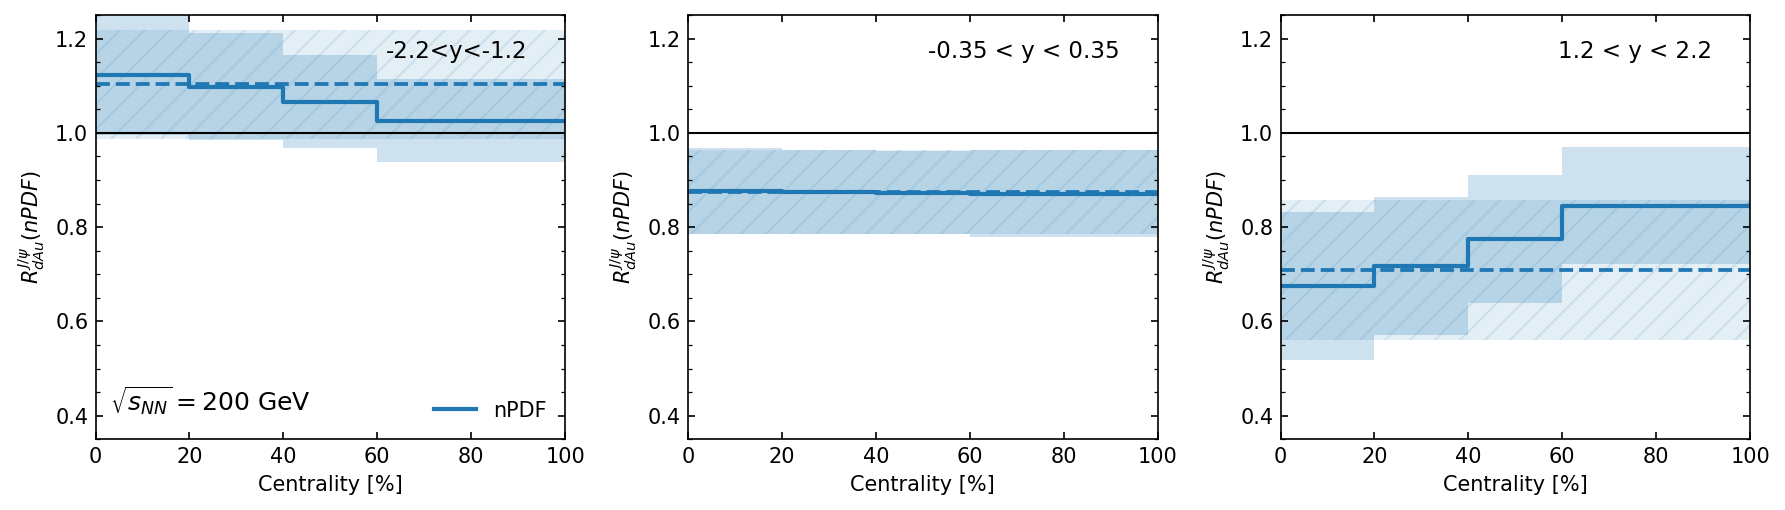

In [8]:
# Ncoll mapping (optical default)
Ncoll_cent, Ncoll_MB = ncoll_by_cent_bins(ctx, optical=True)
print("[Ncoll] bins:", np.round(Ncoll_cent, 3), "MB:", round(Ncoll_MB, 3))

npdf_cent_all = {}

# --- Step plot vs centrality ---
fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.5), dpi=DPI, sharey=False)
axes = np.atleast_1d(axes).ravel()

for ax, (y0, y1, name) in zip(axes, Y_WINDOWS):
    labels, Rc, Rlo, Rhi, mb = npdf_vs_centrality(ctx, (y0,y1), PT_RANGE_AVG)
    npdf_cent_all[name] = (labels, Rc, Rlo, Rhi, mb)

    if SAVE_CSV:
        safe_name = name.replace(" ", "").replace("<","").replace(">","")
        dfc = df_vs_cent(ctx, labels, Rc, Rlo, Rhi, mb, ncoll=Ncoll_cent, ncoll_mb=Ncoll_MB)
        dfc.to_csv(OUTDIR / f"RpA_nPDF_vs_centrality_{safe_name}_{ENERGY.replace('.','p')}TeV.csv", index=False)

    x_edges, y_c  = cent_step_arrays(ctx["cent_bins"], Rc)
    _,       y_lo = cent_step_arrays(ctx["cent_bins"], Rlo)
    _,       y_hi = cent_step_arrays(ctx["cent_bins"], Rhi)

    ax.step(x_edges, y_c, where="post", lw=2.0, color="tab:blue", label="nPDF" if ax is axes[0] else None)
    ax.fill_between(x_edges, y_lo, y_hi, step="post", color="tab:blue", alpha=ALPHA_BAND, linewidth=0.0)
    
    # MB dashed band (same color as nPDF)
    mb_c, mb_lo, mb_hi = mb
    ax.fill_between(
        [0.0, 100.0],
        [mb_lo, mb_lo],
        [mb_hi, mb_hi],
        color="tab:blue",
        alpha=0.12,
        hatch="//",
        linewidth=0.0,
    )
    ax.hlines(
        mb_c, 0.0, 100.0,
        colors="tab:blue",
        linestyles="--",
        linewidth=1.8,
    )

    ax.text(0.92, 0.94, name, transform=ax.transAxes, ha="right", va="top", fontsize=11)
    if ax is axes[0]:
        ax.text(0.03, 0.05, rf"$\sqrt{{s_{{NN}}}}={ctx['sqrt_sNN']:.0f}$ GeV", transform=ax.transAxes,
                ha="left", va="bottom", fontsize=12)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.axhline(1.0, color="k", ls="-", lw=1.0)

    ax.set_xlabel("Centrality [%]")
    ax.set_ylabel(r"$R^{J/\psi}_{dAu} (nPDF)$")
    ax.set_xlim(0, 100)
    ax.set_ylim(0.35, 1.25)
    ax.set_title("")

axes[0].legend(loc="lower right", frameon=False)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(OUTDIR / f"RdAu_nPDF_vs_centrality_{ENERGY.replace('.','p')}TeV.pdf", bbox_inches="tight")
plt.show()

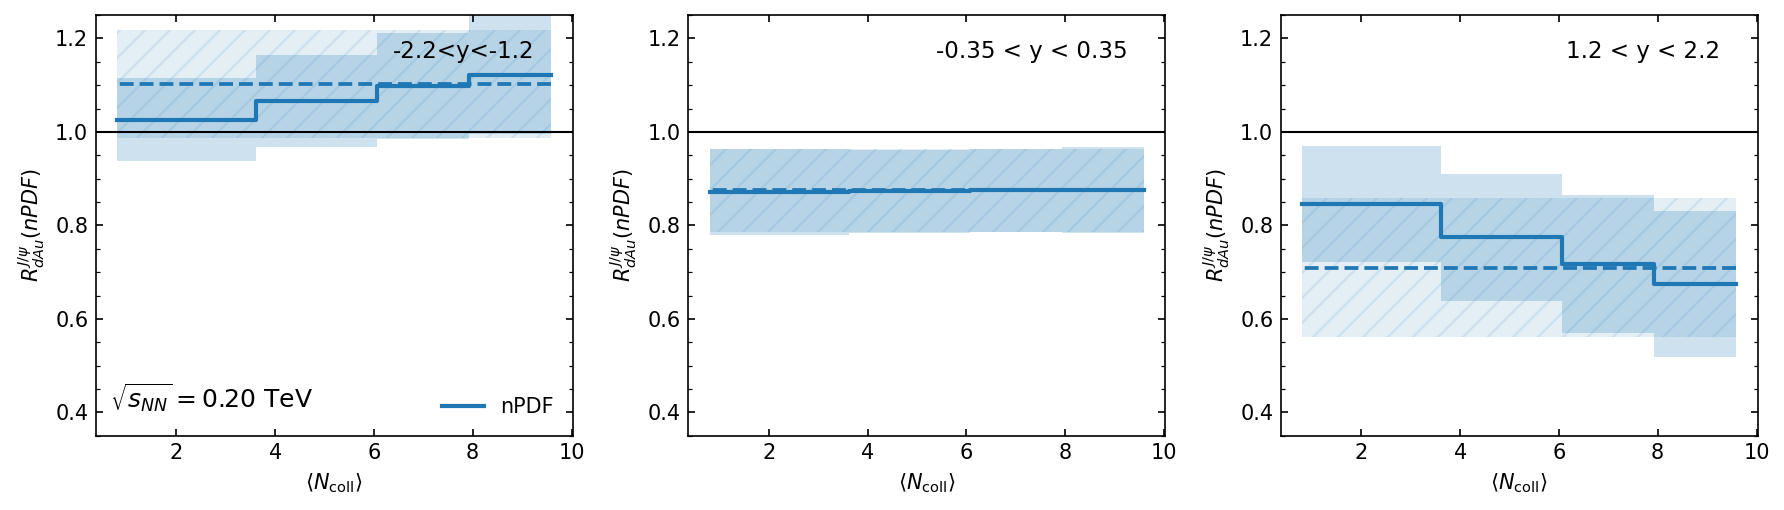

In [9]:
def edges_from_centers(xc):
    xc = np.asarray(xc, float)
    if xc.size < 2:
        dx = 1.0
        return np.array([xc[0]-0.5*dx, xc[0]+0.5*dx], float)
    mids = 0.5*(xc[:-1] + xc[1:])
    left = xc[0] - (mids[0] - xc[0])
    right = xc[-1] + (xc[-1] - mids[-1])
    return np.concatenate([[left], mids, [right]])

# --- Step+band vs <Ncoll> ---
fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.5), dpi=DPI, sharey=False)
axes = np.atleast_1d(axes).ravel()

xN_edges = edges_from_centers(Ncoll_cent)

for ax, (y0, y1, name) in zip(axes, Y_WINDOWS):
    labels, Rc, Rlo, Rhi, mb = npdf_cent_all[name]
    mb_c, mb_lo, mb_hi = mb

    # main band as step vs Ncoll
    y_c  = np.concatenate([Rc,  Rc[-1:]])
    y_lo = np.concatenate([Rlo, Rlo[-1:]])
    y_hi = np.concatenate([Rhi, Rhi[-1:]])

    ax.step(xN_edges, y_c, where="post", lw=2.0, color="tab:blue", label="nPDF" if ax is axes[0] else None)
    ax.fill_between(xN_edges, y_lo, y_hi, step="post", color="tab:blue", alpha=ALPHA_BAND, linewidth=0.0)

    # MB dashed band (same color)
    ax.fill_between(
        [xN_edges[0], xN_edges[-1]],
        [mb_lo, mb_lo],
        [mb_hi, mb_hi],
        color="tab:blue",
        alpha=0.12,
        hatch="//",
        linewidth=0.0,
    )
    ax.hlines(
        mb_c, xN_edges[0], xN_edges[-1],
        colors="tab:blue",
        linestyles="--",
        linewidth=1.8,
    )

    ax.text(0.92, 0.94, name, transform=ax.transAxes, ha="right", va="top", fontsize=11)
    if ax is axes[0]:
        ax.text(0.03, 0.05, rf"$\sqrt{{s_{{NN}}}}={ctx['sqrt_sNN']/1000:.2f}$ TeV",
                transform=ax.transAxes, ha="left", va="bottom", fontsize=12)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.axhline(1.0, color="k", ls="-", lw=1.0)

    ax.set_xlabel(r"$\langle N_{\rm coll}\rangle$")
    ax.set_ylabel(r"$R^{J/\psi}_{dAu} (nPDF)$")
    ax.set_ylim(0.35, 1.25)
    ax.set_title("")

axes[0].legend(loc="lower right", frameon=False)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(OUTDIR / f"RdAu_nPDF_vs_Ncoll_{ENERGY.replace('.','p')}TeV.pdf", bbox_inches="tight")
plt.show()

## $R_{pA}$ vs Rapidity

In [10]:
def npdf_vs_y(ctx, y_edges, pt_range_avg, include_mb=True, mb_c0=MB_C0):
    wcent = make_centrality_weight_dict(ctx["cent_bins"], c0=mb_c0) if include_mb else None

    out = bin_rpa_vs_y(
        ctx["df49_by_cent"], ctx["df_pp"], ctx["df_pa"], ctx["gluon"],
        cent_bins=ctx["cent_bins"],
        y_edges=y_edges,
        pt_range_avg=pt_range_avg,
        weight_mode=WEIGHT_MODE,
        y_ref=Y_REF,
        pt_floor_w=PT_FLOOR_W,
        wcent_dict=wcent,
        include_mb=include_mb,
    )

    y_cent = 0.5*(y_edges[:-1] + y_edges[1:])
    tags = tags_for_cent_bins(ctx["cent_bins"], include_mb=include_mb)
    bands = {
        tag: (np.asarray(out[tag]["r_central"], float),
              np.asarray(out[tag]["r_lo"], float),
              np.asarray(out[tag]["r_hi"], float))
        for tag in tags
    }
    return y_cent, tags, bands


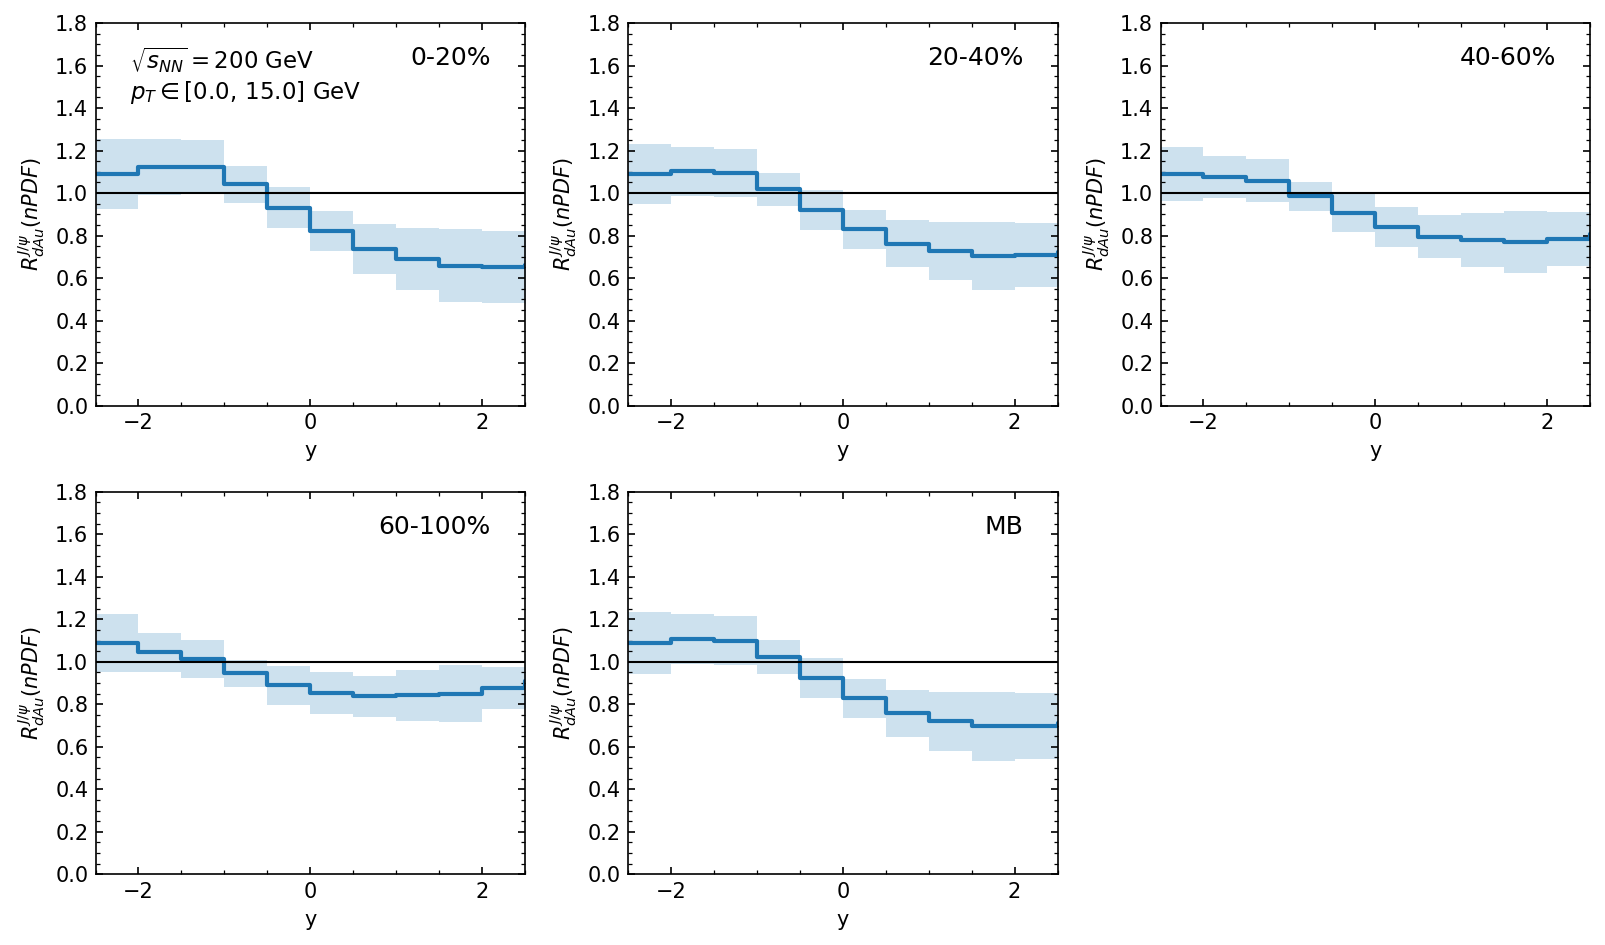

In [11]:
y_cent, tags_y, npdf_y = npdf_vs_y(ctx, Y_EDGES, PT_RANGE_AVG, include_mb=True)

if SAVE_CSV:
    dfy = df_vs_y(y_cent, npdf_y, tags_y)
    dfy.to_csv(OUTDIR / f"RpA_nPDF_vs_y_{ENERGY.replace('.','p')}TeV.csv", index=False)

# panel-per-centrality (like CNM notebook)
n_pan  = len(tags_y)
n_cols = 3
n_rows = int(np.ceil(n_pan / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.6*n_cols, 3.2*n_rows), dpi=DPI, sharex=False, sharey=False)
axes = np.atleast_1d(axes).ravel()

for ip, tag in enumerate(tags_y):
    ax = axes[ip]
    Rc, Rlo, Rhi = npdf_y[tag]

    x_edges, y_c  = step_from_centers(y_cent, Rc)
    _,       y_lo = step_from_centers(y_cent, Rlo)
    _,       y_hi = step_from_centers(y_cent, Rhi)

    ax.step(x_edges, y_c, where="post", lw=2.0, color="tab:blue")
    ax.fill_between(x_edges, y_lo, y_hi, step="post", color="tab:blue", alpha=ALPHA_BAND, linewidth=0.0)

    ax.text(0.92, 0.94, tag, transform=ax.transAxes, ha="right", va="top", fontsize=12)
    if ip == 0:
        ax.text(0.08, 0.94,
                rf"$\sqrt{{s_{{NN}}}}={ctx['sqrt_sNN']:.0f}$ GeV" + "\n" +
                rf"$p_T \in [{PT_RANGE_AVG[0]},\,{PT_RANGE_AVG[1]}]$ GeV",
                transform=ax.transAxes, ha="left", va="top", fontsize=11)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.axhline(1.0, color="k", ls="-", lw=1.0)

    ax.set_xlabel("y")
    ax.set_ylabel(r"$R^{J/\psi}_{dAu} (nPDF)$")
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(0.0, 1.8)
    ax.set_title("")

for k in range(n_pan, len(axes)):
    fig.delaxes(axes[k])

fig.tight_layout()
if SAVE_PDF:
    fig.savefig(OUTDIR / f"RdAu_nPDF_vs_y_{ENERGY.replace('.','p')}GeV.pdf", bbox_inches="tight")
plt.show()

## $R_{pA}$ vs Transverse Momentum

In [12]:
def npdf_vs_pT(ctx, y_window, pt_edges, include_mb=True, mb_c0=MB_C0):
    y0, y1 = y_window
    wcent = make_centrality_weight_dict(ctx["cent_bins"], c0=mb_c0) if include_mb else None

    out = bin_rpa_vs_pT(
        ctx["df49_by_cent"], ctx["df_pp"], ctx["df_pa"], ctx["gluon"],
        cent_bins=ctx["cent_bins"],
        pt_edges=pt_edges,
        y_window=(y0, y1),
        weight_mode=WEIGHT_MODE,
        y_ref=Y_REF,
        pt_floor_w=PT_FLOOR_W,
        wcent_dict=wcent,
        include_mb=include_mb,
    )

    pT_cent = 0.5*(pt_edges[:-1] + pt_edges[1:])
    tags = tags_for_cent_bins(ctx["cent_bins"], include_mb=include_mb)
    bands = {
        tag: (np.asarray(out[tag]["r_central"], float),
              np.asarray(out[tag]["r_lo"], float),
              np.asarray(out[tag]["r_hi"], float))
        for tag in tags
    }
    return pT_cent, tags, bands

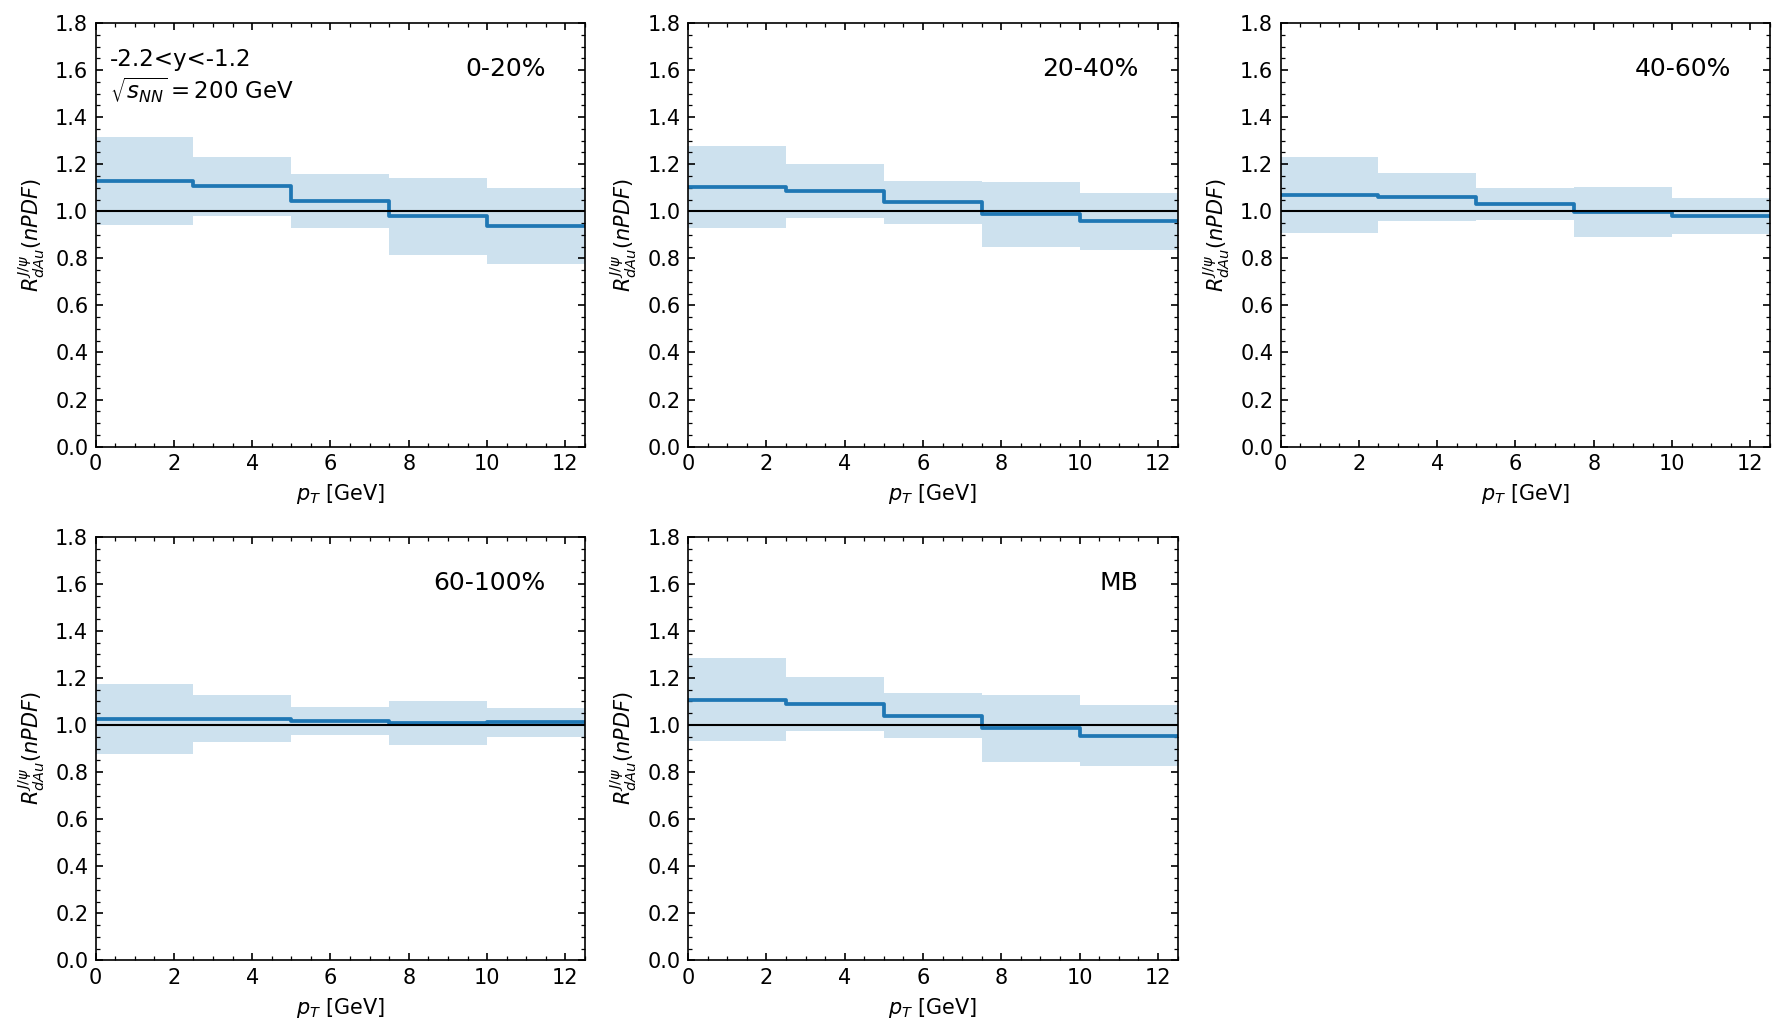

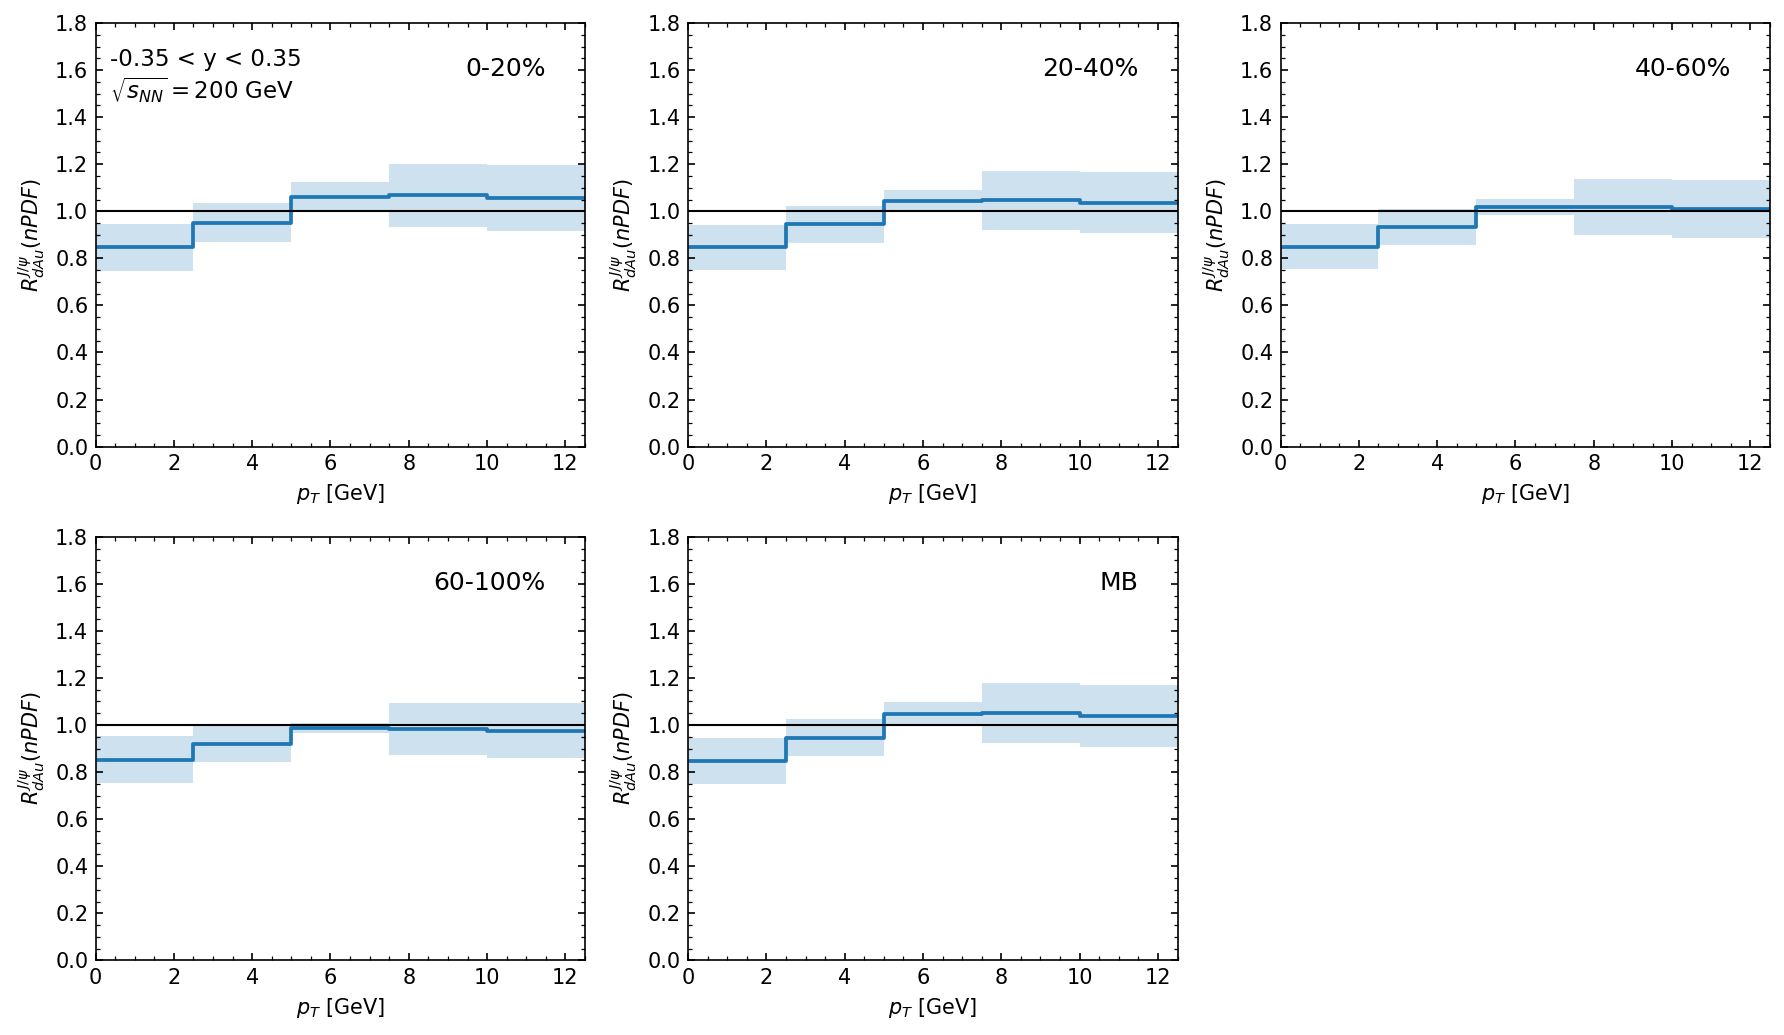

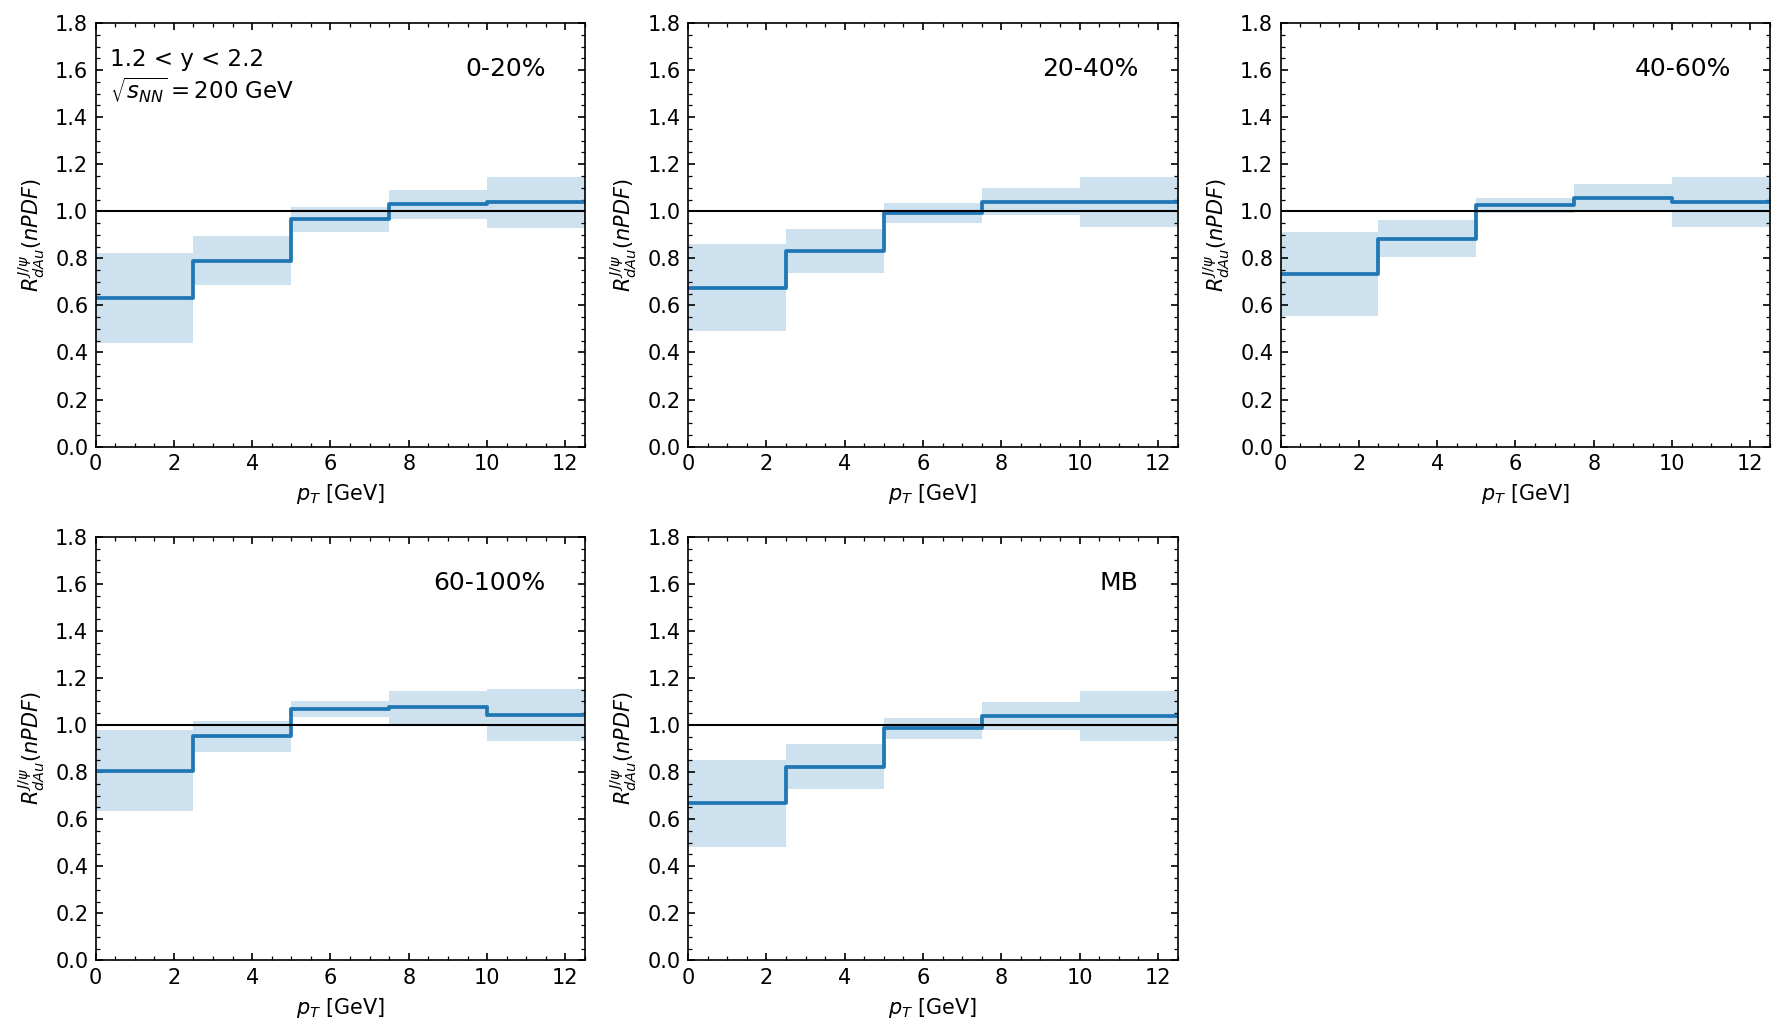

In [13]:
## Plotting vs pT in rapidity windows
for (y0, y1, name) in Y_WINDOWS:
    pT_cent, tags_pt, npdf_pt = npdf_vs_pT(ctx, (y0,y1), P_EDGES, include_mb=True)

    if SAVE_CSV:
        dfpt = df_vs_pT(pT_cent, npdf_pt, tags_pt)
        safe_name = name.replace(" ", "").replace("<","").replace(">","")
        dfpt.to_csv(OUTDIR / f"RpA_nPDF_vs_pT_{safe_name}_{ENERGY.replace('.','p')}TeV.csv", index=False)

    n_pan  = len(tags_pt)
    n_cols = 3
    n_rows = int(np.ceil(n_pan / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0*n_cols, 3.5*n_rows), dpi=DPI, sharex=False, sharey=False)
    axes = np.atleast_1d(axes).ravel()

    for ip, tag in enumerate(tags_pt):
        ax = axes[ip]
        Rc, Rlo, Rhi = npdf_pt[tag]

        x_edges, y_c  = step_from_centers(pT_cent, Rc)
        _,       y_lo = step_from_centers(pT_cent, Rlo)
        _,       y_hi = step_from_centers(pT_cent, Rhi)

        ax.step(x_edges, y_c, where="post", lw=1.8, color="tab:blue")
        ax.fill_between(x_edges, y_lo, y_hi, step="post", color="tab:blue", alpha=ALPHA_BAND, linewidth=0.0)

        ax.text(0.92, 0.92, tag, transform=ax.transAxes, ha="right", va="top", fontsize=12)
        if ip == 0:
            ax.text(0.03, 0.94, f"{name}\n" + rf"$\sqrt{{s_{{NN}}}}={ctx['sqrt_sNN']:.0f}$ GeV",
                    transform=ax.transAxes, ha="left", va="top", fontsize=11)

        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.tick_params(which="both", direction="in", top=True, right=True)
        ax.axhline(1.0, color="k", ls="-", lw=1.0)

        ax.set_xlabel(r"$p_T$ [GeV]")
        ax.set_ylabel(r"$R^{J/\psi}_{dAu} (nPDF)$")
        ax.set_xlim(P_EDGES[0], P_EDGES[-1])
        ax.set_ylim(0.0, 1.8)
        ax.set_title("")

    for k in range(n_pan, len(axes)):
        fig.delaxes(axes[k])

    fig.tight_layout()
    if SAVE_PDF:
        safe_name = name.replace(" ", "_")
        fig.savefig(OUTDIR / f"RdAu_nPDF_vs_pT_{safe_name}_{ENERGY.replace('.','p')}GeV.pdf", bbox_inches="tight")
    plt.show()